# 03 – Temporal Analysis: 2015 vs 2025

**Global Cargo Shipping Network (GCSN)**

This notebook compares the network structure across the two time periods to identify how the global cargo shipping network evolved over a decade.

The 10-year gap (2015→2025) spans several major disruptions:
- COVID-19 pandemic (2020–2021): massive supply chain disruption
- Suez Canal blockage (March 2021): Ever Given incident
- Russia-Ukraine war (2022): Black Sea / Baltic rerouting
- Red Sea / Houthi crisis (2023–2025): Cape of Good Hope rerouting
- Expansion of China's Belt & Road Initiative ports

### Analyses performed
1. Side-by-side summary comparison table (all key metrics)
2. Degree distribution comparison + KS test
3. Strength distribution comparison + KS test
4. Link weight distribution comparison + KS test
5. Node/edge Jaccard overlap (network persistence)
6. Persistent vs new vs lost edges (route evolution)
7. Top ports that gained / lost importance
8. Hub stability (rank correlation)
9. Structural distribution comparison (PDF + CCDF)
10. **New & lost port characterization**
11. **Traffic concentration — Gini coefficient & Lorenz curves**
12. **Network robustness — targeted vs random attack tolerance**
13. **Reciprocity & route directionality**
14. **Visual summary dashboard**
15. Key findings summary


In [68]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
})

FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

COLORS = {'2015': 'steelblue', '2025': 'darkorange'}

print('Imports OK. NetworkX', nx.__version__)


Imports OK. NetworkX 3.4.2


## 1. Load Data and Build All Graphs


In [69]:
df_2015 = pd.read_csv('../EdgeList/shipping_network_2015.csv')
df_2025 = pd.read_csv('../EdgeList/shipping_network_2025.csv')


def build_all_graphs(df):
    """Build directed + undirected, weighted + unweighted graphs."""
    # Directed unweighted
    Gd = nx.DiGraph()
    Gd.add_edges_from(zip(df['source'], df['target']))

    # Undirected unweighted
    Gu = nx.Graph()
    Gu.add_edges_from(zip(df['source'], df['target']))

    # Directed weighted
    Gd_w = nx.from_pandas_edgelist(
        df, 'source', 'target', edge_attr='weight',
        create_using=nx.DiGraph())

    # Undirected weighted
    Gu_w = nx.Graph()
    for _, row in df.iterrows():
        u, v, w = row['source'], row['target'], row['weight']
        if Gu_w.has_edge(u, v):
            Gu_w[u][v]['weight'] += w
        else:
            Gu_w.add_edge(u, v, weight=w)

    return Gd, Gu, Gd_w, Gu_w


print('Building graphs for 2015...')
Gd_2015, Gu_2015, Gd_w_2015, Gu_w_2015 = build_all_graphs(df_2015)
print('  Done.')

print('Building graphs for 2025...')
Gd_2025, Gu_2025, Gd_w_2025, Gu_w_2025 = build_all_graphs(df_2025)
print('  Done.')


def gcc(Gu):
    return Gu.subgraph(max(nx.connected_components(Gu), key=len)).copy()


gcc_2015 = gcc(Gu_2015)
gcc_2025 = gcc(Gu_2025)

for year, Gd, Gu, Gd_w, Gu_w, gcc_g in [
    ('2015', Gd_2015, Gu_2015, Gd_w_2015, Gu_w_2015, gcc_2015),
    ('2025', Gd_2025, Gu_2025, Gd_w_2025, Gu_w_2025, gcc_2025)
]:
    w_arr = np.array([d['weight'] for _, _, d in Gd_w.edges(data=True)])
    print(f'  {year}: N={Gd.number_of_nodes():,}, E_d={Gd.number_of_edges():,},'
          f' E_u={Gu.number_of_edges():,}, total_voyages={w_arr.sum():,},'
          f' GCC_frac={gcc_g.number_of_nodes()/Gu.number_of_nodes()*100:.1f}%')


Building graphs for 2015...
  Done.
Building graphs for 2025...
  Done.
  2015: N=7,097, E_d=188,545, E_u=145,745, total_voyages=1,791,795, GCC_frac=99.8%
  2025: N=7,717, E_d=182,300, E_u=139,499, total_voyages=1,965,325, GCC_frac=99.6%


## Helper Functions


In [70]:
def log_binning(data, n_bins=35):
    data = np.asarray(data, dtype=float)
    data = data[data > 0]
    if len(data) < 2:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins + 1)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    mask = hist > 0
    return centres[mask], hist[mask]


def mle_powerlaw(data, x_min=1):
    data = np.asarray(data, dtype=float)
    data = data[data >= x_min]
    n = len(data)
    if n == 0:
        return np.nan
    return 1.0 + n / np.sum(np.log(data / (x_min - 0.5)))


def sample_apl(G, n=300, seed=42):
    rng = np.random.default_rng(seed)
    nodes = np.array(list(G.nodes()))
    sample = rng.choice(nodes, size=min(n, len(nodes)), replace=False)
    all_d = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        all_d.extend(v for v in lengths.values() if v > 0)
    return float(np.mean(all_d))


print('Helper functions defined.')


Helper functions defined.


## 2. Full Metrics Comparison Table


In [71]:
print('Computing all metrics — this may take a few minutes...')

metrics = {}

for year, Gd, Gu, Gd_w, Gu_w, gcc_g in [
    ('2015', Gd_2015, Gu_2015, Gd_w_2015, Gu_w_2015, gcc_2015),
    ('2025', Gd_2025, Gu_2025, Gd_w_2025, Gu_w_2025, gcc_2025)
]:
    deg_arr      = np.array([d for _, d in Gu.degree()])
    in_deg_arr   = np.array([d for _, d in Gd.in_degree()])
    out_deg_arr  = np.array([d for _, d in Gd.out_degree()])
    w_arr        = np.array([d['weight'] for _, _, d in Gd_w.edges(data=True)])
    strength_arr = np.array([d for _, d in Gu_w.degree(weight='weight')])

    C_unw = nx.average_clustering(Gu)
    C_w   = nx.average_clustering(Gu_w, weight='weight')

    try:
        assort_r = nx.degree_assortativity_coefficient(Gu)
    except Exception:
        assort_r = np.nan

    mu_deg  = mle_powerlaw(deg_arr, x_min=1)
    mu_w    = mle_powerlaw(w_arr,   x_min=1)
    eta_s   = mle_powerlaw(strength_arr, x_min=1)

    print(f'  Computing APL for {year} (sampled)...')
    apl = sample_apl(gcc_g, n=300)
    print(f'    L = {apl:.4f}')

    # Strength-degree alpha
    deg_dict = dict(Gu_w.degree())
    str_dict = dict(Gu_w.degree(weight='weight'))
    k_all = np.array([deg_dict[n] for n in Gu_w.nodes() if deg_dict[n] > 0])
    s_all = np.array([str_dict[n] for n in Gu_w.nodes() if deg_dict[n] > 0])
    if len(k_all) > 3 and k_all.max() > k_all.min():
        alpha_val, _, _, _, _ = stats.linregress(np.log10(k_all), np.log10(s_all))
    else:
        alpha_val = np.nan

    metrics[year] = {
        'N': Gu.number_of_nodes(),
        'E_directed': Gd.number_of_edges(),
        'E_undirected': Gu.number_of_edges(),
        'density_d': nx.density(Gd),
        'density_u': nx.density(Gu),
        'mean_k': float(deg_arr.mean()),
        'max_k': int(deg_arr.max()),
        'mean_in': float(in_deg_arr.mean()),
        'mean_out': float(out_deg_arr.mean()),
        'C_unw': C_unw,
        'C_w': C_w,
        'apl': apl,
        'assort_r': assort_r,
        'mu_deg': mu_deg,
        'total_voyages': int(w_arr.sum()),
        'mean_J': float(w_arr.mean()),
        'max_w': int(w_arr.max()),
        'mean_s': float(strength_arr.mean()),
        'mu_w': mu_w,
        'eta_s': eta_s,
        'alpha': alpha_val,
        'n_comps': nx.number_connected_components(Gu),
        'gcc_frac': gcc_g.number_of_nodes() / Gu.number_of_nodes(),
        'scc': nx.number_strongly_connected_components(Gd),
        'wcc': nx.number_weakly_connected_components(Gd),
    }

m15, m25 = metrics['2015'], metrics['2025']


def pct_change(a, b):
    """Percentage change from a to b."""
    if a == 0:
        return 'N/A'
    return f'{(b - a) / abs(a) * 100:+.1f}%'


rows = [
    ('TOPOLOGY', '', '', ''),
    ('Nodes N',                          f'{m15["N"]:,}',             f'{m25["N"]:,}',             pct_change(m15['N'],           m25['N'])),
    ('Directed edges',                   f'{m15["E_directed"]:,}',    f'{m25["E_directed"]:,}',    pct_change(m15['E_directed'],  m25['E_directed'])),
    ('Undirected edges',                 f'{m15["E_undirected"]:,}',  f'{m25["E_undirected"]:,}',  pct_change(m15['E_undirected'],m25['E_undirected'])),
    ('Density (directed)',               f'{m15["density_d"]:.6f}',   f'{m25["density_d"]:.6f}',   pct_change(m15['density_d'],   m25['density_d'])),
    ('Connected components',             f'{m15["n_comps"]}',         f'{m25["n_comps"]}',         pct_change(m15['n_comps'],     m25['n_comps'])),
    ('SCCs (directed)',                  f'{m15["scc"]}',             f'{m25["scc"]}',             pct_change(m15['scc'],         m25['scc'])),
    ('GCC fraction of N',               f'{m15["gcc_frac"]*100:.1f}%', f'{m25["gcc_frac"]*100:.1f}%', ''),
    ('DEGREE', '', '', ''),
    ('Mean undirected degree <k>',       f'{m15["mean_k"]:.2f}',      f'{m25["mean_k"]:.2f}',      pct_change(m15['mean_k'],      m25['mean_k'])),
    ('Mean in-degree',                   f'{m15["mean_in"]:.2f}',     f'{m25["mean_in"]:.2f}',     pct_change(m15['mean_in'],     m25['mean_in'])),
    ('Max undirected degree',            f'{m15["max_k"]:,}',         f'{m25["max_k"]:,}',         pct_change(m15['max_k'],       m25['max_k'])),
    ('Degree power-law exponent mu',     f'{m15["mu_deg"]:.3f}',      f'{m25["mu_deg"]:.3f}',      ''),
    ('CLUSTERING & PATH LENGTH', '', '', ''),
    ('Clustering C (unweighted)',        f'{m15["C_unw"]:.4f}',       f'{m25["C_unw"]:.4f}',       pct_change(m15['C_unw'],       m25['C_unw'])),
    ('Clustering C (weighted)',          f'{m15["C_w"]:.4f}',         f'{m25["C_w"]:.4f}',         pct_change(m15['C_w'],         m25['C_w'])),
    ('Avg path length L (sampled GCC)', f'{m15["apl"]:.4f}',         f'{m25["apl"]:.4f}',         pct_change(m15['apl'],         m25['apl'])),
    ('Assortativity r',                  f'{m15["assort_r"]:.4f}',    f'{m25["assort_r"]:.4f}',    pct_change(m15['assort_r'],    m25['assort_r'])),
    ('WEIGHTS & TRAFFIC', '', '', ''),
    ('Total voyages',                    f'{m15["total_voyages"]:,}',  f'{m25["total_voyages"]:,}',  pct_change(m15['total_voyages'], m25['total_voyages'])),
    ('Mean journeys per link <J>',       f'{m15["mean_J"]:.2f}',      f'{m25["mean_J"]:.2f}',      pct_change(m15['mean_J'],      m25['mean_J'])),
    ('Max link weight',                  f'{m15["max_w"]:,}',         f'{m25["max_w"]:,}',         pct_change(m15['max_w'],       m25['max_w'])),
    ('Mean node strength <s>',           f'{m15["mean_s"]:.1f}',      f'{m25["mean_s"]:.1f}',      pct_change(m15['mean_s'],      m25['mean_s'])),
    ('Link weight exponent mu_w',        f'{m15["mu_w"]:.3f}',        f'{m25["mu_w"]:.3f}',        ''),
    ('Strength exponent eta',            f'{m15["eta_s"]:.3f}',       f'{m25["eta_s"]:.3f}',       ''),
    ('Strength-degree scaling alpha',    f'{m15["alpha"]:.3f}',       f'{m25["alpha"]:.3f}',       ''),
]

df_cmp = pd.DataFrame(rows, columns=['Metric', '2015', '2025', 'Change'])

print()
print('=' * 75)
print('  GCSN — 2015 vs 2025 FULL COMPARISON')
print('=' * 75)
print(df_cmp.to_string(index=False))
print('=' * 75)

df_cmp.to_csv('../Figures/03_comparison_table.csv', index=False)
print('\nTable saved to ../Figures/03_comparison_table.csv')


Computing all metrics — this may take a few minutes...
  Computing APL for 2015 (sampled)...
    L = 3.2889
  Computing APL for 2025 (sampled)...
    L = 3.5765

  GCSN — 2015 vs 2025 FULL COMPARISON
                         Metric      2015      2025 Change
                       TOPOLOGY                           
                        Nodes N     7,097     7,717  +8.7%
                 Directed edges   188,545   182,300  -3.3%
               Undirected edges   145,745   139,499  -4.3%
             Density (directed)  0.003744  0.003062 -18.2%
           Connected components         8         5 -37.5%
                SCCs (directed)       219       203  -7.3%
              GCC fraction of N     99.8%     99.6%       
                         DEGREE                           
     Mean undirected degree <k>     41.07     36.15 -12.0%
                 Mean in-degree     26.57     23.62 -11.1%
          Max undirected degree     1,233     1,171  -5.0%
   Degree power-law exponent mu  

## 3. Distribution Comparisons with KS Tests

The **Kolmogorov-Smirnov (KS) test** compares two empirical distributions.  
A small p-value (< 0.05) means the distributions are statistically different.


KS Test Results
Distribution                 KS stat      p-value   Significant?
---------------------------------------------------------------
Degree P(k)                   0.0286   4.6116e-03            YES
Strength P(s)                 0.0181   1.7269e-01             no
Link weight P(w)              0.0256   2.1996e-53            YES


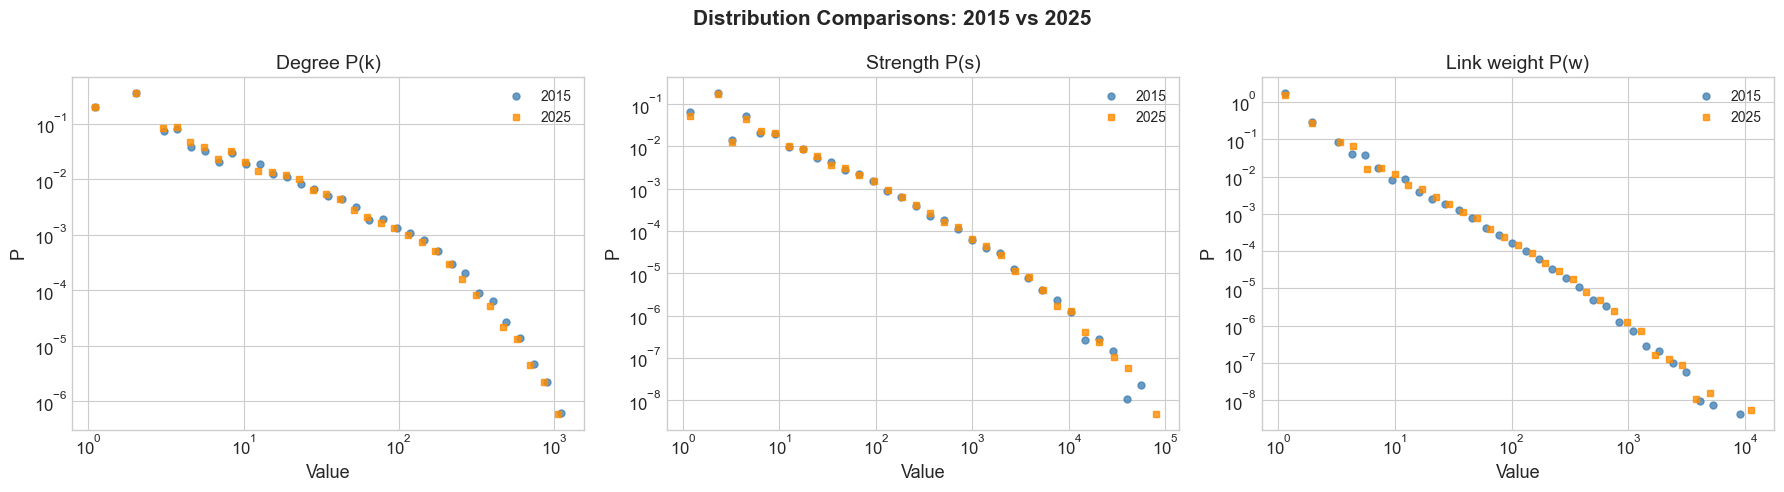

In [72]:
deg_2015 = np.array([d for _, d in Gu_2015.degree()])
deg_2025 = np.array([d for _, d in Gu_2025.degree()])

str_2015 = np.array([d for _, d in Gu_w_2015.degree(weight='weight')])
str_2025 = np.array([d for _, d in Gu_w_2025.degree(weight='weight')])

w_2015 = np.array([d['weight'] for _, _, d in Gd_w_2015.edges(data=True)])
w_2025 = np.array([d['weight'] for _, _, d in Gd_w_2025.edges(data=True)])

ks_deg = stats.ks_2samp(deg_2015, deg_2025)
ks_str = stats.ks_2samp(str_2015, str_2025)
ks_w   = stats.ks_2samp(w_2015,   w_2025)

print('KS Test Results')
print(f'{"Distribution":<25} {"KS stat":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 63)
for name, ks in [('Degree P(k)', ks_deg), ('Strength P(s)', ks_str), ('Link weight P(w)', ks_w)]:
    sig = 'YES' if ks.pvalue < 0.05 else 'no'
    print(f'{name:<25} {ks.statistic:>10.4f} {ks.pvalue:>12.4e} {sig:>14}')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Comparisons: 2015 vs 2025', fontsize=15, fontweight='bold')

for ax, (name, d15, d25) in zip(axes, [
    ('Degree P(k)',         deg_2015, deg_2025),
    ('Strength P(s)',       str_2015, str_2025),
    ('Link weight P(w)',    w_2015,   w_2025),
]):
    x15, p15 = log_binning(d15)
    x25, p25 = log_binning(d25)
    ax.loglog(x15, p15, 'o', ms=5, alpha=0.8, color=COLORS['2015'], label='2015')
    ax.loglog(x25, p25, 's', ms=5, alpha=0.8, color=COLORS['2025'], label='2025')
    ax.set_xlabel('Value')
    ax.set_ylabel('P')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '03_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Network Overlap: Jaccard Similarity

Jaccard index = |A ∩ B| / |A ∪ B|  
Measures what fraction of nodes/edges are shared between the two years.

- J ≈ 1 → nearly identical networks
- J ≈ 0 → completely different



  NETWORK OVERLAP: 2015 vs 2025
  NODES
    2015 nodes       :    7,097
    2025 nodes       :    7,717
    Common (both)    :    5,728
    New in 2025      :    1,989
    Lost from 2015   :    1,369
    Jaccard (nodes)  :   0.6304
  DIRECTED EDGES
    2015 edges       :  188,545
    2025 edges       :  182,300
    Common (both)    :   78,741
    New in 2025      :  103,559
    Lost from 2015   :  109,804
    Jaccard (d-edges):   0.2696
  UNDIRECTED EDGES
    Jaccard (u-edges):   0.1898


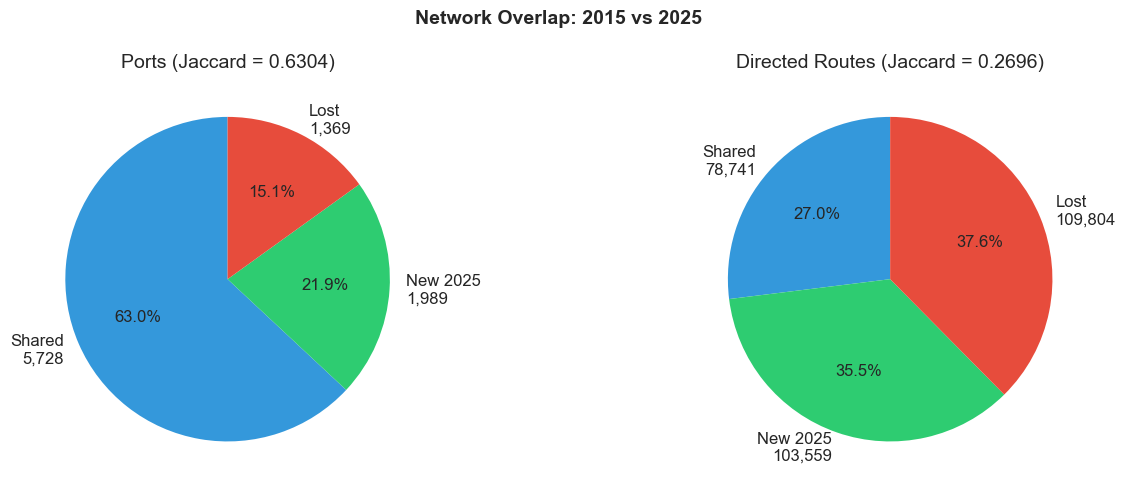

In [73]:
nodes_15 = set(Gu_2015.nodes())
nodes_25 = set(Gu_2025.nodes())

edges_15_d = set(Gd_2015.edges())
edges_25_d = set(Gd_2025.edges())
edges_15_u = set(Gu_2015.edges())
edges_25_u = set(Gu_2025.edges())

# Jaccard
J_nodes   = len(nodes_15 & nodes_25) / len(nodes_15 | nodes_25)
J_edges_d = len(edges_15_d & edges_25_d) / len(edges_15_d | edges_25_d)
J_edges_u = len(edges_15_u & edges_25_u) / len(edges_15_u | edges_25_u)

# Sets
nodes_new    = nodes_25 - nodes_15
nodes_lost   = nodes_15 - nodes_25
nodes_common = nodes_15 & nodes_25

edges_new_d    = edges_25_d - edges_15_d
edges_lost_d   = edges_15_d - edges_25_d
edges_common_d = edges_15_d & edges_25_d

print(f'\n{"="*65}')
print(f'  NETWORK OVERLAP: 2015 vs 2025')
print(f'{"="*65}')
print(f'  NODES')
print(f'    2015 nodes       : {len(nodes_15):>8,}')
print(f'    2025 nodes       : {len(nodes_25):>8,}')
print(f'    Common (both)    : {len(nodes_common):>8,}')
print(f'    New in 2025      : {len(nodes_new):>8,}')
print(f'    Lost from 2015   : {len(nodes_lost):>8,}')
print(f'    Jaccard (nodes)  : {J_nodes:>8.4f}')
print(f'  DIRECTED EDGES')
print(f'    2015 edges       : {len(edges_15_d):>8,}')
print(f'    2025 edges       : {len(edges_25_d):>8,}')
print(f'    Common (both)    : {len(edges_common_d):>8,}')
print(f'    New in 2025      : {len(edges_new_d):>8,}')
print(f'    Lost from 2015   : {len(edges_lost_d):>8,}')
print(f'    Jaccard (d-edges): {J_edges_d:>8.4f}')
print(f'  UNDIRECTED EDGES')
print(f'    Jaccard (u-edges): {J_edges_u:>8.4f}')
print(f'{"="*65}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Network Overlap: 2015 vs 2025', fontsize=14, fontweight='bold')

# Nodes pie
axes[0].pie(
    [len(nodes_common), len(nodes_new), len(nodes_lost)],
    labels=[
        f'Shared\n{len(nodes_common):,}',
        f'New 2025\n{len(nodes_new):,}',
        f'Lost\n{len(nodes_lost):,}'
    ],
    autopct='%1.1f%%',
    colors=['#3498db', '#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title(f'Ports (Jaccard = {J_nodes:.4f})')

# Edges pie
axes[1].pie(
    [len(edges_common_d), len(edges_new_d), len(edges_lost_d)],
    labels=[
        f'Shared\n{len(edges_common_d):,}',
        f'New 2025\n{len(edges_new_d):,}',
        f'Lost\n{len(edges_lost_d):,}'
    ],
    autopct='%1.1f%%',
    colors=['#3498db', '#2ecc71', '#e74c3c'],
    startangle=90
)
axes[1].set_title(f'Directed Routes (Jaccard = {J_edges_d:.4f})')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Route Weight Changes: Persistent Routes

For routes present in **both** 2015 and 2025, we examine how traffic volume changed.


Persistent routes (present both years): 78,741
Routes with increased traffic: 33,117
Routes with decreased traffic: 30,812
Unchanged routes: 14,812


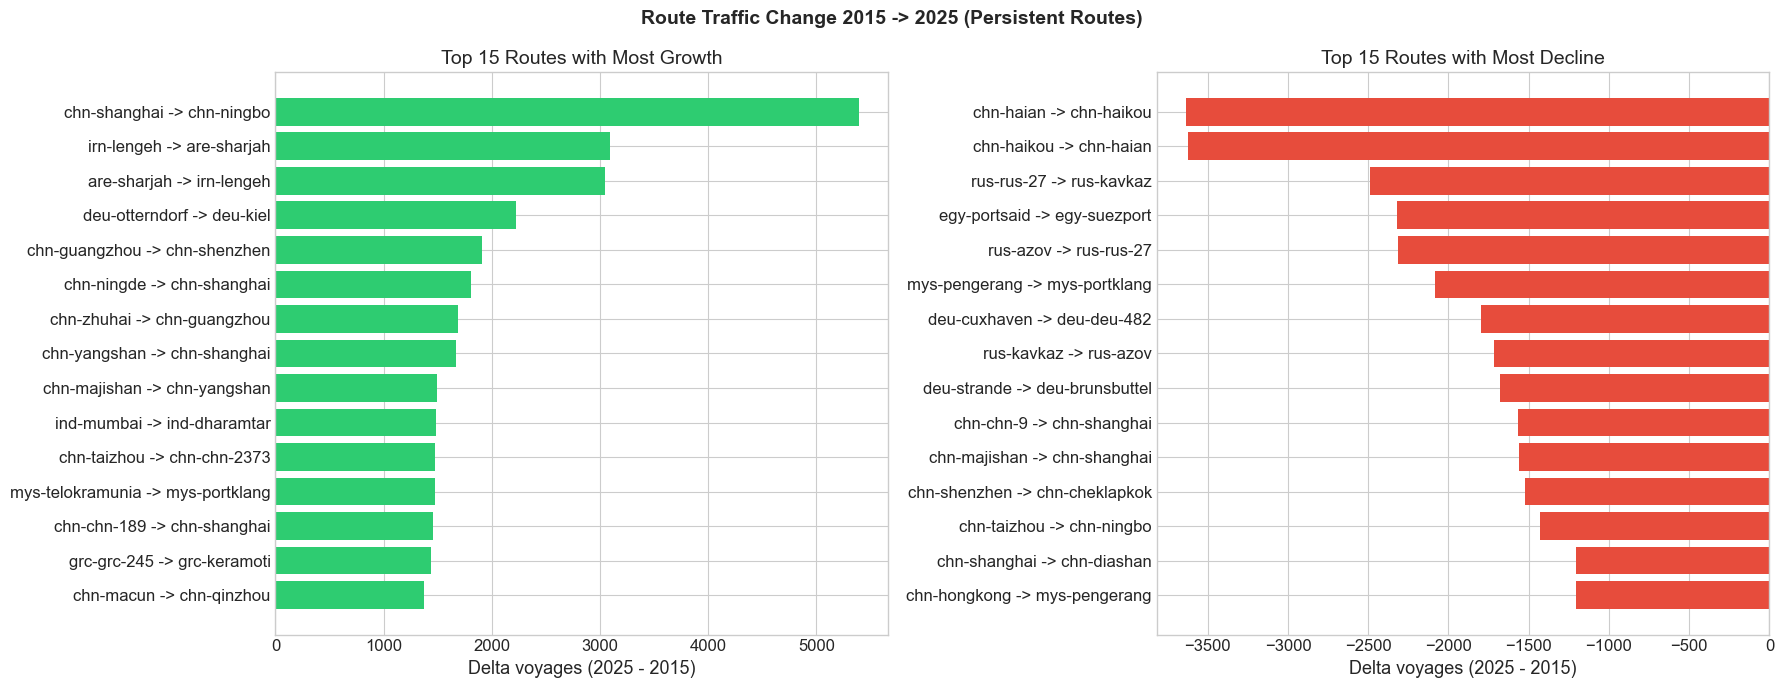


Top 15 routes with most growth:
                            route  w_2015  w_2025  delta    pct_change
       chn-shanghai -> chn-ningbo    5328   10722   5394    101.238739
        irn-lengeh -> are-sharjah     148    3240   3092   2089.189189
        are-sharjah -> irn-lengeh     144    3190   3046   2115.277778
       deu-otterndorf -> deu-kiel     843    3064   2221    263.463820
    chn-guangzhou -> chn-shenzhen    2821    4728   1907     67.600142
       chn-ningde -> chn-shanghai     331    2135   1804    545.015106
      chn-zhuhai -> chn-guangzhou     779    2466   1687    216.559692
     chn-yangshan -> chn-shanghai    3097    4769   1672     53.987730
     chn-majishan -> chn-yangshan     115    1606   1491   1296.521739
      ind-mumbai -> ind-dharamtar      15    1495   1480   9866.666667
      chn-taizhou -> chn-chn-2373    1825    3301   1476     80.876712
mys-telokramunia -> mys-portklang     806    2277   1471    182.506203
      chn-chn-189 -> chn-shanghai     957   

In [74]:
# Build weight dicts for directed graphs
w_dict_2015 = {(r['source'], r['target']): r['weight'] for _, r in df_2015.iterrows()}
w_dict_2025 = {(r['source'], r['target']): r['weight'] for _, r in df_2025.iterrows()}

# Persistent routes (in both years)
common_routes = edges_15_d & edges_25_d

delta_rows = []
for (u, v) in common_routes:
    w15 = w_dict_2015.get((u, v), 0)
    w25 = w_dict_2025.get((u, v), 0)
    delta = w25 - w15
    pct   = (w25 - w15) / max(w15, 1) * 100
    delta_rows.append({'source': u, 'target': v,
                       'w_2015': w15, 'w_2025': w25,
                       'delta': delta, 'pct_change': pct})

df_delta = pd.DataFrame(delta_rows).sort_values('delta', ascending=False)

print(f'Persistent routes (present both years): {len(df_delta):,}')
print(f'Routes with increased traffic: {(df_delta["delta"] > 0).sum():,}')
print(f'Routes with decreased traffic: {(df_delta["delta"] < 0).sum():,}')
print(f'Unchanged routes: {(df_delta["delta"] == 0).sum():,}')

# Top gainers
top_n = 15
df_gainers = df_delta.nlargest(top_n, 'delta')
df_losers  = df_delta.nsmallest(top_n, 'delta')

df_gainers['route'] = df_gainers['source'] + ' -> ' + df_gainers['target']
df_losers['route']  = df_losers['source']  + ' -> ' + df_losers['target']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Route Traffic Change 2015 -> 2025 (Persistent Routes)', fontsize=14, fontweight='bold')

axes[0].barh(df_gainers['route'][::-1], df_gainers['delta'][::-1],
             color='#2ecc71', edgecolor='none')
axes[0].set_xlabel('Delta voyages (2025 - 2015)')
axes[0].set_title(f'Top {top_n} Routes with Most Growth')

axes[1].barh(df_losers['route'][::-1], df_losers['delta'][::-1],
             color='#e74c3c', edgecolor='none')
axes[1].set_xlabel('Delta voyages (2025 - 2015)')
axes[1].set_title(f'Top {top_n} Routes with Most Decline')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_route_changes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 15 routes with most growth:')
print(df_gainers[['route', 'w_2015', 'w_2025', 'delta', 'pct_change']].to_string(index=False))
print('\nTop 15 routes with most decline:')
print(df_losers[['route', 'w_2015', 'w_2025', 'delta', 'pct_change']].to_string(index=False))


## 6. Port Importance Evolution

Ports that rose and fell in **strength** (traffic) between 2015 and 2025.


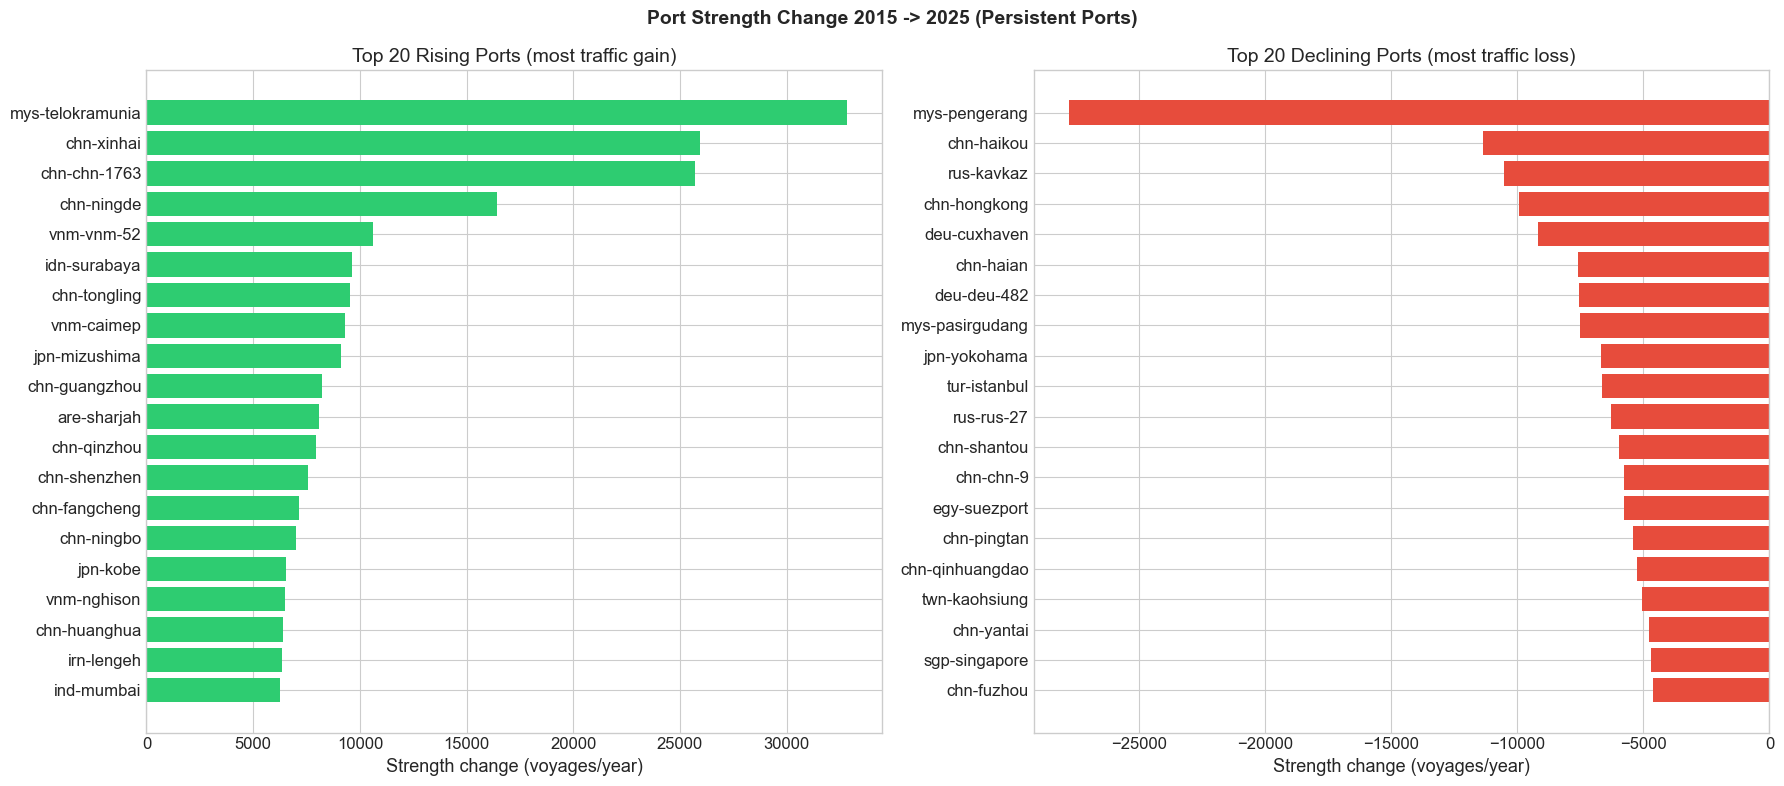

Top 20 ports with most strength growth:
            port  s_2015  s_2025  s_delta        s_pct  k_delta
mys-telokramunia   10009   42848    32839   328.094715      385
      chn-xinhai      57   25984    25927 45485.964912       10
    chn-chn-1763      54   25751    25697 47587.037037        7
      chn-ningde    8097   24523    16426   202.865259      104
      vnm-vnm-52    5491   16097    10606   193.152431       86
    idn-surabaya    7482   17129     9647   128.936113       36
    chn-tongling      55    9580     9525 17318.181818      262
      vnm-caimep    3517   12814     9297   264.344612      146
   jpn-mizushima    9837   18954     9117    92.680695       13
   chn-guangzhou   23510   31752     8242    35.057422       81
     are-sharjah    3478   11559     8081   232.346176       -6
     chn-qinzhou    6986   14912     7926   113.455482       68
    chn-shenzhen   27246   34810     7564    27.761873       91
   chn-fangcheng    5913   13076     7163   121.139861       25


In [75]:
s_2015 = dict(Gu_w_2015.degree(weight='weight'))
s_2025 = dict(Gu_w_2025.degree(weight='weight'))
k_2015 = dict(Gu_2015.degree())
k_2025 = dict(Gu_2025.degree())

common_ports = set(s_2015.keys()) & set(s_2025.keys())

port_rows = []
for port in common_ports:
    s15 = s_2015[port]
    s25 = s_2025[port]
    k15 = k_2015[port]
    k25 = k_2025[port]
    port_rows.append({
        'port': port,
        's_2015': s15, 's_2025': s25,
        's_delta': s25 - s15,
        's_pct': (s25 - s15) / max(s15, 1) * 100,
        'k_2015': k15, 'k_2025': k25,
        'k_delta': k25 - k15,
    })

df_ports = pd.DataFrame(port_rows)

# Top risers and fallers by strength
top_n = 20
top_risers  = df_ports.nlargest(top_n,  's_delta')
top_fallers = df_ports.nsmallest(top_n, 's_delta')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Port Strength Change 2015 -> 2025 (Persistent Ports)', fontsize=14, fontweight='bold')

axes[0].barh(top_risers['port'][::-1], top_risers['s_delta'][::-1],
             color='#2ecc71', edgecolor='none')
axes[0].set_xlabel('Strength change (voyages/year)')
axes[0].set_title(f'Top {top_n} Rising Ports (most traffic gain)')

axes[1].barh(top_fallers['port'][::-1], top_fallers['s_delta'][::-1],
             color='#e74c3c', edgecolor='none')
axes[1].set_xlabel('Strength change (voyages/year)')
axes[1].set_title(f'Top {top_n} Declining Ports (most traffic loss)')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_port_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 ports with most strength growth:')
print(top_risers[['port', 's_2015', 's_2025', 's_delta', 's_pct', 'k_delta']].to_string(index=False))
print('\nTop 20 ports with most strength decline:')
print(top_fallers[['port', 's_2015', 's_2025', 's_delta', 's_pct', 'k_delta']].to_string(index=False))


## 7. Hub Stability: Rank Correlation of Top Ports

Do the same ports dominate both years? We compute Spearman rank correlation of port degrees across both years.


Spearman rank correlation (degree):   rho = 0.7726  (p = 0.00e+00)
Spearman rank correlation (strength):  rho = 0.7587  (p = 0.00e+00)

rho close to 1 -> same ports dominate in both years (stable hub structure).
rho close to 0 -> port rankings reshuffled significantly.


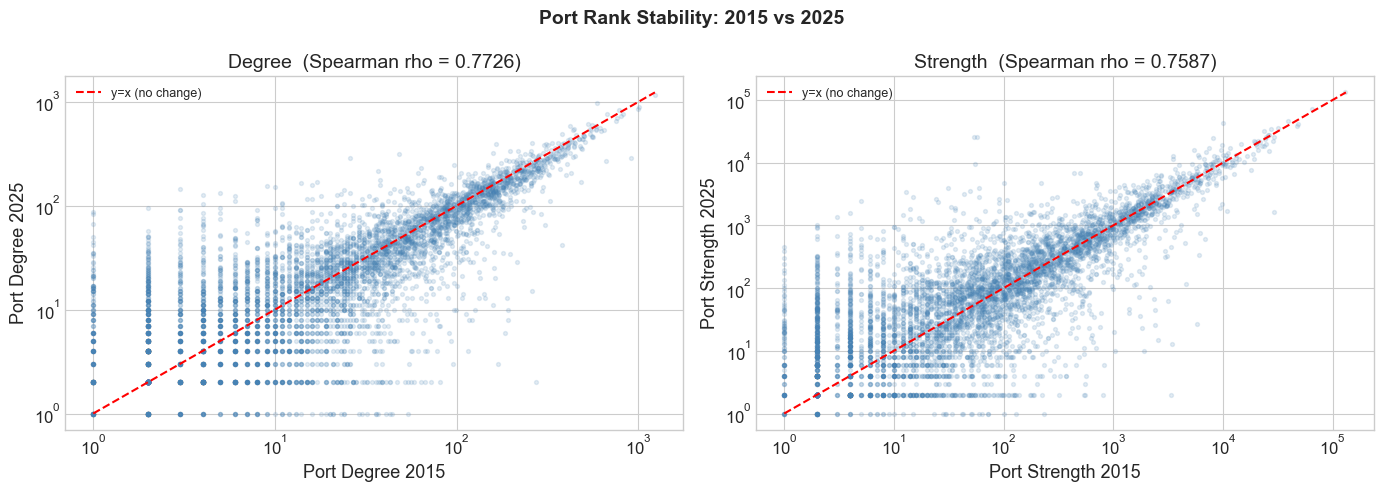

In [76]:
common_ports_list = sorted(common_ports)

k15_vec = np.array([k_2015[p] for p in common_ports_list])
k25_vec = np.array([k_2025[p] for p in common_ports_list])
s15_vec = np.array([s_2015[p] for p in common_ports_list])
s25_vec = np.array([s_2025[p] for p in common_ports_list])

rho_k, pval_k = stats.spearmanr(k15_vec, k25_vec)
rho_s, pval_s = stats.spearmanr(s15_vec, s25_vec)

print(f'Spearman rank correlation (degree):   rho = {rho_k:.4f}  (p = {pval_k:.2e})')
print(f'Spearman rank correlation (strength):  rho = {rho_s:.4f}  (p = {pval_s:.2e})')
print()
print('rho close to 1 -> same ports dominate in both years (stable hub structure).')
print('rho close to 0 -> port rankings reshuffled significantly.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Port Rank Stability: 2015 vs 2025', fontsize=14, fontweight='bold')

for ax, (v15, v25, label, rho, pval) in zip(axes, [
    (k15_vec, k25_vec, 'Degree', rho_k, pval_k),
    (s15_vec, s25_vec, 'Strength', rho_s, pval_s),
]):
    ax.scatter(v15, v25, alpha=0.15, s=8, color='steelblue')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'Port {label} 2015')
    ax.set_ylabel(f'Port {label} 2025')
    ax.set_title(f'{label}  (Spearman rho = {rho:.4f})')
    # y=x reference
    mn = min(v15.min(), v25.min())
    mx = max(v15.max(), v25.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='y=x (no change)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '03_hub_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Structural Change: Weight Distribution Shift

Plot the full degree and weight distributions side-by-side with CCDF to visually assess structural shifts.


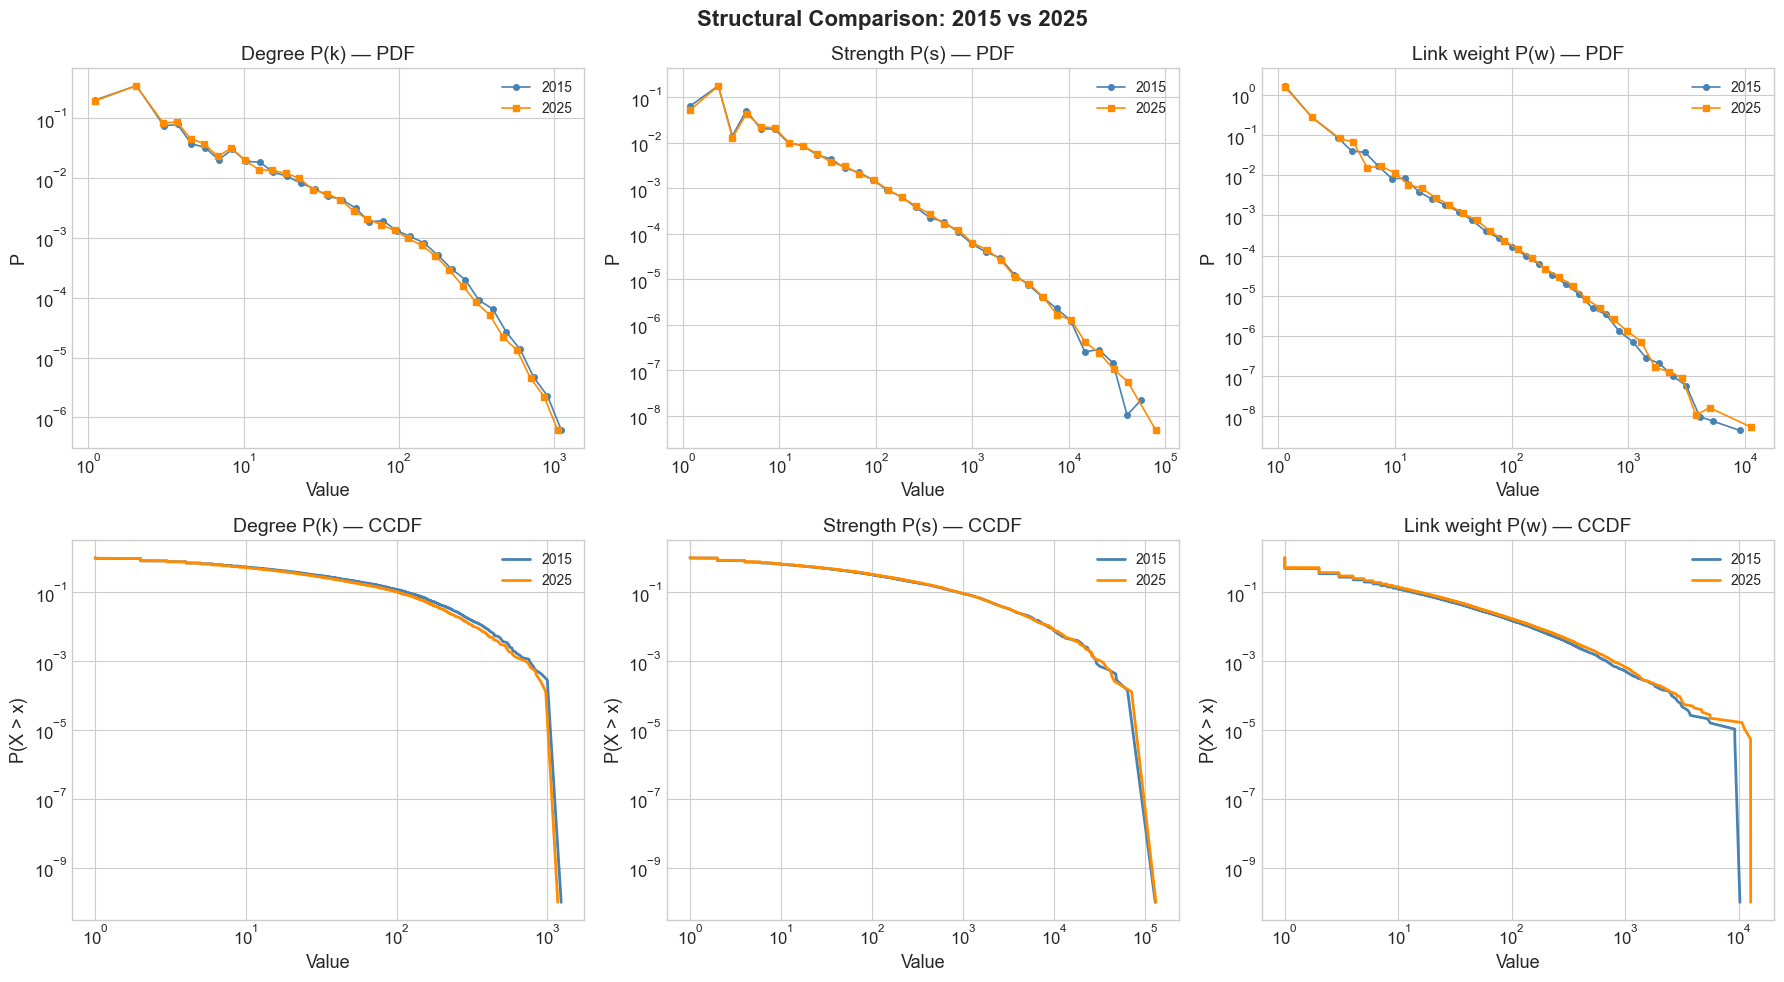

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Structural Comparison: 2015 vs 2025', fontsize=16, fontweight='bold')

def ccdf(data):
    x = np.sort(data)
    y = 1 - np.arange(1, len(x)+1) / len(x)
    return x, y

datasets = [
    ('Degree P(k)',    deg_2015, deg_2025),
    ('Strength P(s)',  str_2015, str_2025),
    ('Link weight P(w)', w_2015, w_2025),
]

for col, (name, d15, d25) in enumerate(datasets):
    # PDF (log-binned)
    ax = axes[0, col]
    x15, p15 = log_binning(d15)
    x25, p25 = log_binning(d25)
    if len(x15): ax.loglog(x15, p15, 'o-', ms=4, lw=1.2, color=COLORS['2015'], label='2015')
    if len(x25): ax.loglog(x25, p25, 's-', ms=4, lw=1.2, color=COLORS['2025'], label='2025')
    ax.set_xlabel('Value')
    ax.set_ylabel('P')
    ax.set_title(f'{name} — PDF')
    ax.legend()

    # CCDF
    ax2 = axes[1, col]
    xc15, yc15 = ccdf(d15)
    xc25, yc25 = ccdf(d25)
    ax2.loglog(xc15, yc15 + 1e-10, '-', lw=2, color=COLORS['2015'], label='2015')
    ax2.loglog(xc25, yc25 + 1e-10, '-', lw=2, color=COLORS['2025'], label='2025')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('P(X > x)')
    ax2.set_title(f'{name} — CCDF')
    ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '03_structural_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Key Findings Summary


In [78]:
print()
print('=' * 72)
print('  GCSN TEMPORAL ANALYSIS — KEY FINDINGS (2015 -> 2025)')
print('=' * 72)

# Node/Edge change
dn = m25['N'] - m15['N']
de = m25['E_directed'] - m15['E_directed']
print(f'\n  1. NETWORK SIZE')
print(f'     Ports (nodes):    {m15["N"]:>6,} -> {m25["N"]:>6,}  ({dn:+,}, {dn/m15["N"]*100:+.1f}%)')
print(f'     Routes (d-edges): {m15["E_directed"]:>6,} -> {m25["E_directed"]:>6,}  ({de:+,}, {de/m15["E_directed"]*100:+.1f}%)')
print(f'     Route overlap (Jaccard): {J_edges_d:.4f}')
print(f'     {len(edges_new_d):,} new routes appeared; {len(edges_lost_d):,} routes disappeared.')

print(f'\n  2. CONNECTIVITY & SMALL-WORLD')
print(f'     Mean degree <k>: {m15["mean_k"]:.2f} -> {m25["mean_k"]:.2f}')
print(f'     Clustering C:    {m15["C_unw"]:.4f} -> {m25["C_unw"]:.4f}')
print(f'     Path length L:   {m15["apl"]:.4f} -> {m25["apl"]:.4f}')

print(f'\n  3. TRAFFIC VOLUME')
print(f'     Total voyages:   {m15["total_voyages"]:,} -> {m25["total_voyages"]:,}')
print(f'     Mean J per link: {m15["mean_J"]:.2f} -> {m25["mean_J"]:.2f}')

print(f'\n  4. POWER-LAW EXPONENTS')
print(f'     Degree mu:    {m15["mu_deg"]:.3f} -> {m25["mu_deg"]:.3f}')
print(f'     Strength eta: {m15["eta_s"]:.3f} -> {m25["eta_s"]:.3f}')
print(f'     Weight mu_w:  {m15["mu_w"]:.3f} -> {m25["mu_w"]:.3f}')
print(f'     Scaling alpha (s~k^a): {m15["alpha"]:.3f} -> {m25["alpha"]:.3f}')

print(f'\n  5. HUB STABILITY')
print(f'     Spearman rho (degree):   {rho_k:.4f}')
print(f'     Spearman rho (strength): {rho_s:.4f}')
print(f'     => Hub structure is {"STABLE" if rho_k > 0.7 else "MODERATELY STABLE" if rho_k > 0.4 else "RESHUFFLED"}')

print(f'\n  6. KS TESTS (2015 vs 2025 distributions)')
print(f'     Degree:   KS={ks_deg.statistic:.4f}  p={ks_deg.pvalue:.3e}  {"DIFFERENT" if ks_deg.pvalue<0.05 else "similar"}')
print(f'     Strength: KS={ks_str.statistic:.4f}  p={ks_str.pvalue:.3e}  {"DIFFERENT" if ks_str.pvalue<0.05 else "similar"}')
print(f'     Weight:   KS={ks_w.statistic:.4f}  p={ks_w.pvalue:.3e}  {"DIFFERENT" if ks_w.pvalue<0.05 else "similar"}')

print()
print('=' * 72)

# Save summary


  GCSN TEMPORAL ANALYSIS — KEY FINDINGS (2015 -> 2025)

  1. NETWORK SIZE
     Ports (nodes):     7,097 ->  7,717  (+620, +8.7%)
     Routes (d-edges): 188,545 -> 182,300  (-6,245, -3.3%)
     Route overlap (Jaccard): 0.2696
     103,559 new routes appeared; 109,804 routes disappeared.

  2. CONNECTIVITY & SMALL-WORLD
     Mean degree <k>: 41.07 -> 36.15
     Clustering C:    0.5223 -> 0.4884
     Path length L:   3.2889 -> 3.5765

  3. TRAFFIC VOLUME
     Total voyages:   1,791,795 -> 1,965,325
     Mean J per link: 9.50 -> 10.78

  4. POWER-LAW EXPONENTS
     Degree mu:    1.306 -> 1.314
     Strength eta: 1.236 -> 1.233
     Weight mu_w:  1.643 -> 1.617
     Scaling alpha (s~k^a): 1.408 -> 1.425

  5. HUB STABILITY
     Spearman rho (degree):   0.7726
     Spearman rho (strength): 0.7587
     => Hub structure is STABLE

  6. KS TESTS (2015 vs 2025 distributions)
     Degree:   KS=0.0286  p=4.612e-03  DIFFERENT
     Strength: KS=0.0181  p=1.727e-01  similar
     Weight:   KS=0.0256 

---
## 10. New & Lost Port Characterization

Ports that **entered** the network between 2015 and 2025 (new routes opened) and ports that **exited** (routes closed entirely).

Ranking by their 2025 (new) or 2015 (lost) degree reveals whether these are minor peripheral ports or significant nodes that shifted in/out of the network.

New ports (2025 only) : 1,989  — top 25 by 2025 degree:
           Port  Degree  In-deg  Out-deg  Strength
       idn-weda     219     157      133      2007
     pan-pan-42     133      56      116       884
alb-portoromano     115      62       92       638
   chn-chn-1055     101      62       80      1234
    chn-chn-300      89      64       56       286
    pan-melones      75      32       61       261
    chn-chn-942      67      47       53       533
   chn-chn-1295      62      29       43       588
   chn-chn-2042      59      41       36       323
  cmr-bombemgue      56      37       42       573
   chn-chn-1293      55      38       29       960
    chn-chn-816      54      29       38       770
    chn-chn-864      52      41       34       254
    chn-chn-958      51      33       34       206
    per-chancay      51      38       38       662
  nor-gudvangen      50      31       21       116
   chn-chn-1216      49      41       30       169
    chn-chn-883      48   

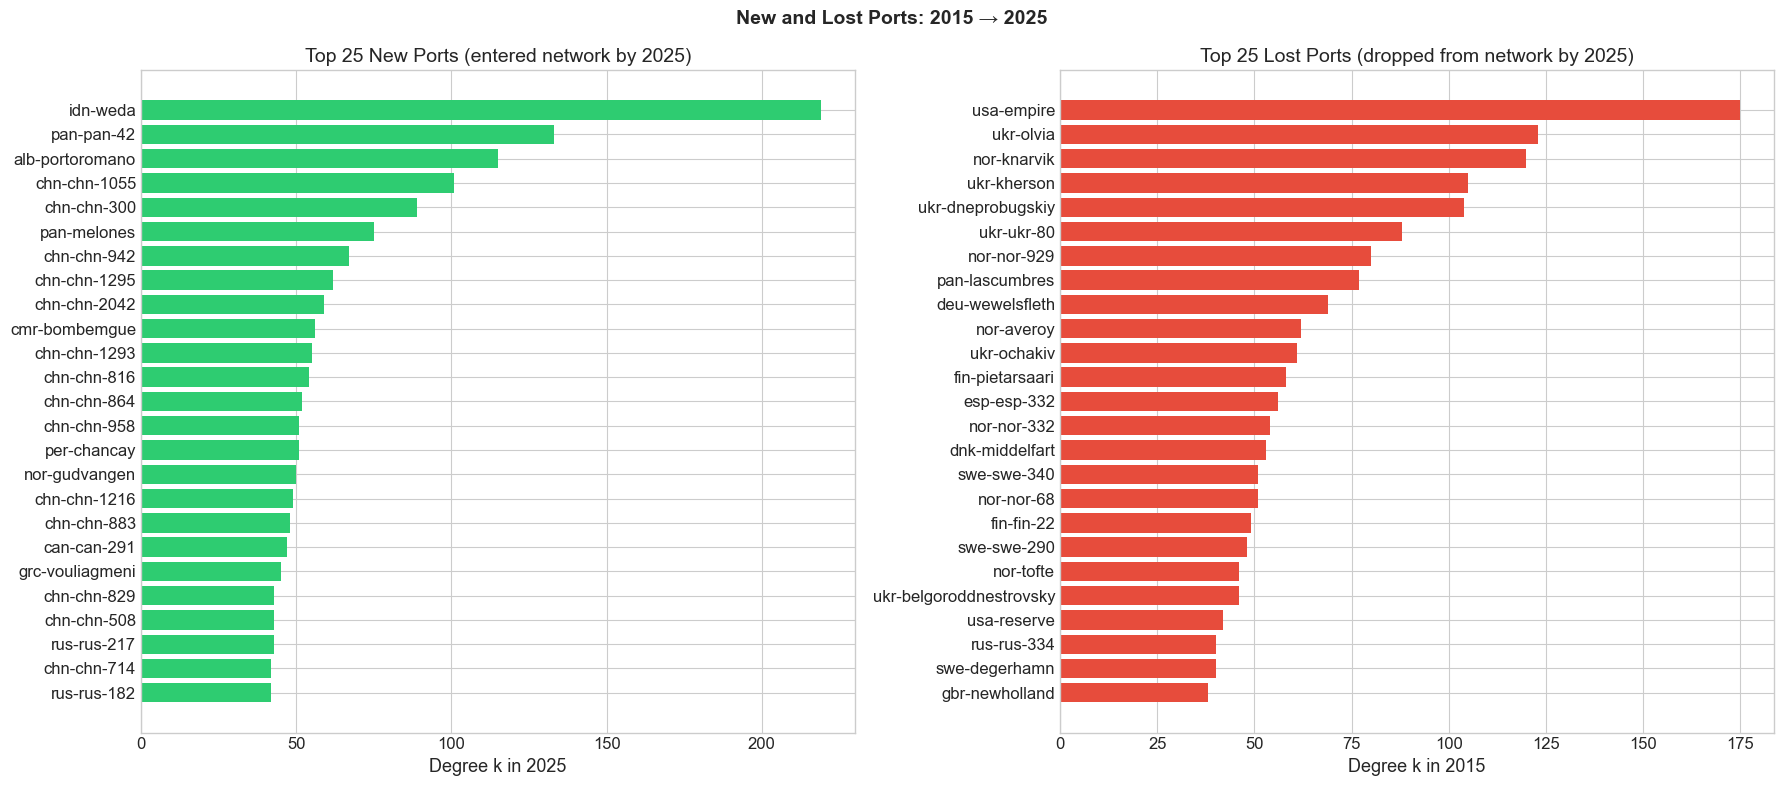


Mean degree of new  ports: 67.64
Mean degree of lost ports: 69.44
-> Large hubs entered the 2025 network


In [79]:
TOP_NL = 25

# New ports: appear in 2025 but not 2015
new_ports  = sorted(nodes_25 - nodes_15,
                    key=lambda p: Gu_2025.degree(p), reverse=True)
# Lost ports: in 2015 but not 2025
lost_ports = sorted(nodes_15 - nodes_25,
                    key=lambda p: Gu_2015.degree(p), reverse=True)

def port_profile(port_list, G_year, Gd_year, Gd_w_year, year_label, top_n=TOP_NL):
    rows = []
    for p in port_list[:top_n]:
        in_d  = Gd_year.in_degree(p)
        out_d = Gd_year.out_degree(p)
        s     = sum(d['weight'] for _, _, d in Gd_w_year.in_edges(p, data=True)) + \
                sum(d['weight'] for _, _, d in Gd_w_year.out_edges(p, data=True))
        rows.append({'Port': p, 'Degree': G_year.degree(p),
                     'In-deg': in_d, 'Out-deg': out_d, 'Strength': s})
    return pd.DataFrame(rows)


df_new  = port_profile(new_ports,  Gu_2025, Gd_2025, Gd_w_2025, '2025')
df_lost = port_profile(lost_ports, Gu_2015, Gd_2015, Gd_w_2015, '2015')

print(f'New ports (2025 only) : {len(new_ports):,}  — top {TOP_NL} by 2025 degree:')
print(df_new.to_string(index=False))
print()
print(f'Lost ports (2015 only): {len(lost_ports):,}  — top {TOP_NL} by 2015 degree:')
print(df_lost.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('New and Lost Ports: 2015 → 2025', fontsize=14, fontweight='bold')

axes[0].barh(df_new['Port'][::-1], df_new['Degree'][::-1],
             color='#2ecc71', edgecolor='none')
axes[0].set_xlabel('Degree k in 2025')
axes[0].set_title(f'Top {TOP_NL} New Ports (entered network by 2025)')

axes[1].barh(df_lost['Port'][::-1], df_lost['Degree'][::-1],
             color='#e74c3c', edgecolor='none')
axes[1].set_xlabel('Degree k in 2015')
axes[1].set_title(f'Top {TOP_NL} Lost Ports (dropped from network by 2025)')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_new_lost_ports.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMean degree of new  ports: {df_new["Degree"].mean():.2f}')
print(f'Mean degree of lost ports: {df_lost["Degree"].mean():.2f}')
print(f'-> {"Large hubs entered" if df_new["Degree"].mean() > 5 else "Mostly peripheral ports entered"} the 2025 network')


---
## 11. Traffic Concentration — Gini Coefficient & Lorenz Curves

The **Gini coefficient** (0 = perfectly equal, 1 = all traffic on one route) measures how unevenly traffic is distributed across routes and ports.

The **Lorenz curve** shows what fraction of total traffic is carried by the bottom X% of routes/ports.

A rising Gini over time means traffic is becoming **more concentrated** on a smaller number of hub routes — typical of winner-takes-all network dynamics.

Gini coefficients (0=equal, 1=maximally concentrated):
  Metric                     2015     2025     Change
  --------------------------------------------------
  Route weight (P(w))      0.8093   0.8186  +0.0092  ≈ stable
  Port strength (P(s))     0.8892   0.8854  -0.0039  ≈ stable
  Port degree (P(k))       0.7046   0.7006  -0.0039  ≈ stable


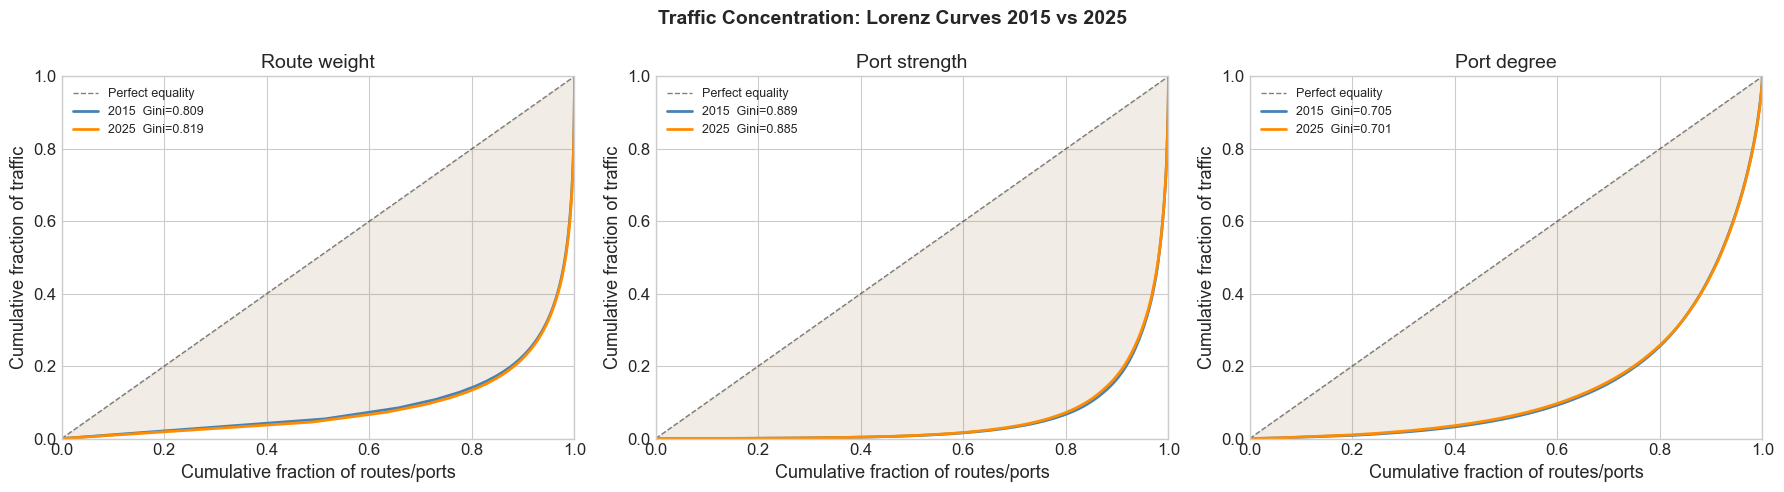

  2015: top 10% routes carry 77.2% of traffic;  top 1% carry 40.8%
  2025: top 10% routes carry 77.8% of traffic;  top 1% carry 41.6%


In [80]:
def gini(arr):
    """Gini coefficient of a 1-D non-negative array."""
    arr = np.sort(np.asarray(arr, dtype=float))
    arr = arr[arr > 0]
    n = len(arr)
    if n == 0:
        return np.nan
    cumsum = np.cumsum(arr)
    return (2 * np.sum((np.arange(1, n+1)) * arr) - (n+1) * cumsum[-1]) / (n * cumsum[-1])


def lorenz_curve(arr):
    """Returns (cum_pop_fraction, cum_value_fraction) for a Lorenz curve."""
    arr = np.sort(np.asarray(arr, dtype=float))
    arr = arr[arr > 0]
    cum_val = np.cumsum(arr) / arr.sum()
    cum_pop = np.arange(1, len(arr)+1) / len(arr)
    return cum_pop, cum_val


# Compute Gini for edges (route weights) and nodes (port strength)
g_w15  = gini(w_2015);     g_w25  = gini(w_2025)
g_s15  = gini(str_2015);   g_s25  = gini(str_2025)
g_k15  = gini(deg_2015);   g_k25  = gini(deg_2025)

print(f'Gini coefficients (0=equal, 1=maximally concentrated):')
print(f'  {"Metric":<22} {"2015":>8} {"2025":>8} {"Change":>10}')
print(f'  {"-"*50}')
for label, g15, g25 in [
    ('Route weight (P(w))',  g_w15, g_w25),
    ('Port strength (P(s))', g_s15, g_s25),
    ('Port degree (P(k))',   g_k15, g_k25),
]:
    chg = g25 - g15
    direction = '▲ more concentrated' if chg > 0.01 else ('▼ less concentrated' if chg < -0.01 else '≈ stable')
    print(f'  {label:<22} {g15:>8.4f} {g25:>8.4f} {chg:>+8.4f}  {direction}')

# --- Lorenz curve plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Traffic Concentration: Lorenz Curves 2015 vs 2025',
             fontsize=14, fontweight='bold')

for ax, (label, d15, d25, g15, g25) in zip(axes, [
    ('Route weight',  w_2015,   w_2025,   g_w15, g_w25),
    ('Port strength', str_2015, str_2025, g_s15, g_s25),
    ('Port degree',   deg_2015, deg_2025, g_k15, g_k25),
]):
    x15, y15 = lorenz_curve(d15)
    x25, y25 = lorenz_curve(d25)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Perfect equality')
    ax.plot(x15, y15, '-', lw=2, color=COLORS['2015'],
            label=f'2015  Gini={g15:.3f}')
    ax.plot(x25, y25, '-', lw=2, color=COLORS['2025'],
            label=f'2025  Gini={g25:.3f}')

    ax.fill_between(x15, x15, y15, alpha=0.08, color=COLORS['2015'])
    ax.fill_between(x25, x25, y25, alpha=0.08, color=COLORS['2025'])

    ax.set_xlabel('Cumulative fraction of routes/ports')
    ax.set_ylabel('Cumulative fraction of traffic')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR + '03_lorenz_gini.png', dpi=150, bbox_inches='tight')
plt.show()

# --- concentration statistic: top 10% of routes carry X% of traffic ---
for year, w_arr in [('2015', w_2015), ('2025', w_2025)]:
    w_sorted = np.sort(w_arr)[::-1]
    total    = w_sorted.sum()
    top10    = int(len(w_sorted) * 0.10)
    top1     = int(len(w_sorted) * 0.01)
    print(f'  {year}: top 10% routes carry {w_sorted[:top10].sum()/total*100:.1f}% of traffic;' 
          f'  top 1% carry {w_sorted[:top1].sum()/total*100:.1f}%')


---
## 12. Network Robustness — Targeted vs Random Attack Tolerance

How does the Giant Connected Component (GCC) shrink when nodes are removed?

- **Targeted attack**: remove nodes in decreasing degree order (simulates failure/disruption of the most connected ports)
- **Random failure**: remove nodes uniformly at random (simulates random port closures)

A network that is resilient to random failures but fragile under targeted attack is characteristic of **scale-free** topology.  We compare the robustness profiles of 2015 and 2025 to see if the network became more or less resilient over the decade.

Computing robustness curves (4 curves, ~1–2 min each) …
  2015 targeted …
  2015 random   …
  2025 targeted …
  2025 random   …


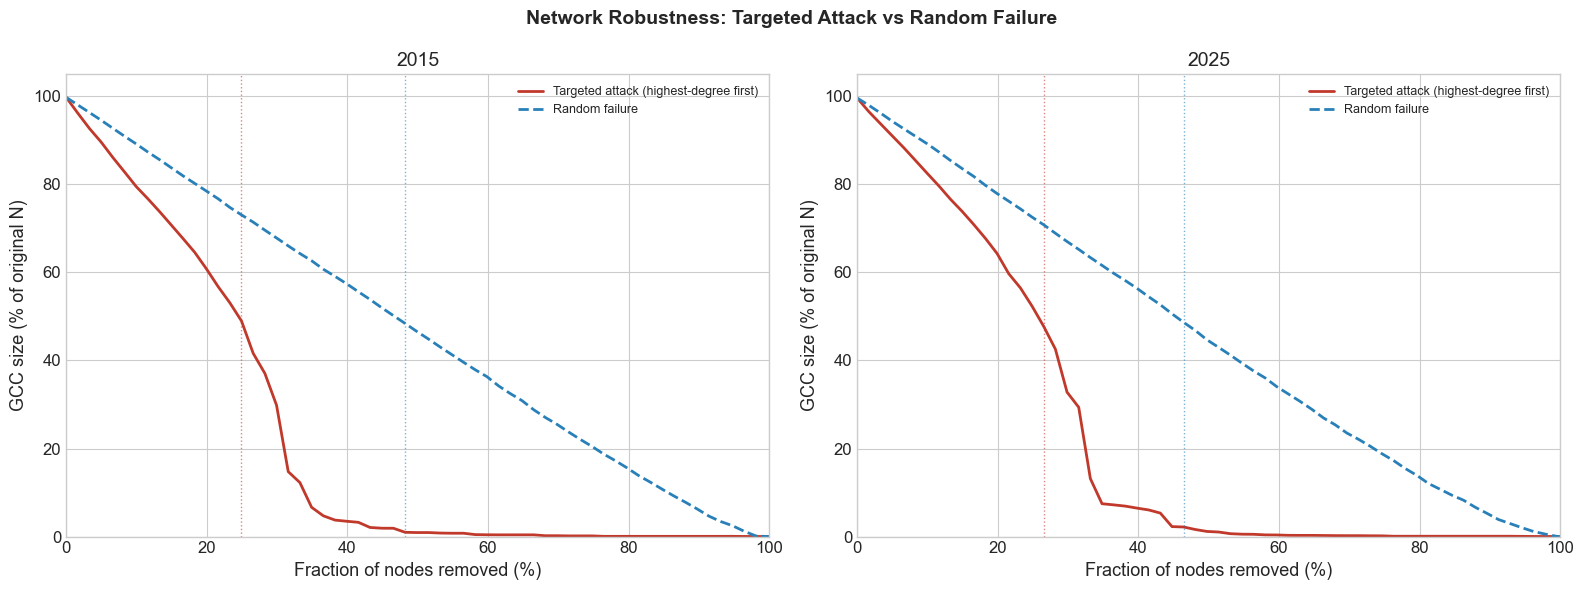


Robustness summary (fraction removed to halve GCC):
  Year   Strategy     f₅₀ (node fraction)
  ----------------------------------------
  2015   targeted      0.249  (24.9% of nodes)
  2015   random        0.482  (48.2% of nodes)
  2025   targeted      0.265  (26.5% of nodes)
  2025   random        0.464  (46.4% of nodes)

Smaller f₅₀ for targeted → hub-dependent (scale-free character)
Larger   f₅₀ for targeted in 2025 → improved robustness over decade


In [81]:
def robustness_curve(Gu, strategy='targeted', n_steps=50, seed=42):
    """Compute GCC fraction as nodes are incrementally removed.

    strategy: 'targeted' (highest degree first) or 'random'
    n_steps: number of evenly-spaced checkpoints (0% to 100% removed)
    Returns (fractions_removed, gcc_fractions)
    """
    G = Gu.copy()
    N0 = G.number_of_nodes()
    if N0 == 0:
        return np.array([0.0]), np.array([0.0])

    rng = np.random.default_rng(seed)
    checkpoints = np.linspace(0, 1, n_steps + 1)
    gcc_fracs   = [max((len(c) for c in nx.connected_components(G)), default=0) / N0]
    frac_done   = [0.0]

    if strategy == 'targeted':
        order = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
    else:
        order = list(G.nodes())
        rng.shuffle(order)

    step_size = max(1, N0 // n_steps)
    removed   = 0
    for i, node in enumerate(order):
        if not G.has_node(node):
            continue
        G.remove_node(node)
        removed += 1
        if removed % step_size == 0 or removed == N0:
            gcc = max((len(c) for c in nx.connected_components(G)), default=0)
            gcc_fracs.append(gcc / N0)
            frac_done.append(removed / N0)

    return np.array(frac_done), np.array(gcc_fracs)


N_STEPS = 60

print('Computing robustness curves (4 curves, ~1–2 min each) …')

rob = {}
for year, Gu in [('2015', Gu_2015), ('2025', Gu_2025)]:
    print(f'  {year} targeted …')
    rob[(year, 'targeted')] = robustness_curve(Gu, strategy='targeted', n_steps=N_STEPS)
    print(f'  {year} random   …')
    rob[(year, 'random')]   = robustness_curve(Gu, strategy='random',   n_steps=N_STEPS)

# --- Robustness metric: fraction removed to reduce GCC to < 50% ---
def f50(frac_removed, gcc_frac):
    """Fraction of nodes removed when GCC first drops below 50%."""
    for f, g in zip(frac_removed, gcc_frac):
        if g < 0.5:
            return f
    return 1.0


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Network Robustness: Targeted Attack vs Random Failure',
             fontsize=14, fontweight='bold')

styles = {'targeted': ('-', 'Targeted attack (highest-degree first)'),
          'random':   ('--', 'Random failure')}

for ax, year, title in [(axes[0], '2015', '2015'), (axes[1], '2025', '2025')]:
    for strategy, (ls, label) in styles.items():
        fr, gf = rob[(year, strategy)]
        color  = '#c0392b' if strategy == 'targeted' else '#2980b9'
        ax.plot(fr * 100, gf * 100, ls, color=color, lw=2, label=label)
        f = f50(fr, gf)
        ax.axvline(f * 100, color=color, lw=1, ls=':', alpha=0.6)

    ax.set_xlabel('Fraction of nodes removed (%)')
    ax.set_ylabel('GCC size (% of original N)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIG_DIR + '03_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRobustness summary (fraction removed to halve GCC):')
print(f'  {"Year":<6} {"Strategy":<12} {"f₅₀ (node fraction)"}')
print(f'  {"-"*40}')
for (year, strat), (fr, gf) in rob.items():
    f = f50(fr, gf)
    print(f'  {year:<6} {strat:<12}  {f:.3f}  ({f*100:.1f}% of nodes)')
print('\nSmaller f₅₀ for targeted → hub-dependent (scale-free character)')
print('Larger   f₅₀ for targeted in 2025 → improved robustness over decade')


---
## 13. Reciprocity & Route Directionality

**Reciprocity** = fraction of directed edges (u→v) that have a return edge (v→u).  A reciprocity of 1 means every route is bidirectional; 0 means all routes are one-way.

Changes in reciprocity reveal whether the network has become more symmetric (balanced trade flows) or more asymmetric (dominant import/export hubs).

We also look at the weight asymmetry of reciprocated routes — whether traffic in both directions is balanced or dominated by one direction.

Overall reciprocity:
  2015: 0.4540  (45.4% of edges are reciprocated)
  2025: 0.4696  (47.0% of edges are reciprocated)
  Change: +0.0156  (more bidirectional in 2025)

2015: 85,600 reciprocated edges, 102,945 one-way edges
2025: 85,602 reciprocated edges, 96,698 one-way edges
  2015: mean weight asymmetry = 0.3362  (0=balanced, 1=one-directional)
  2025: mean weight asymmetry = 0.3399  (0=balanced, 1=one-directional)

Among routes present in both years:
  Gained reciprocation (2015 one-way → 2025 bidirectional): 9,590
  Lost  reciprocation (2015 bidirectional → 2025 one-way) : 9,996


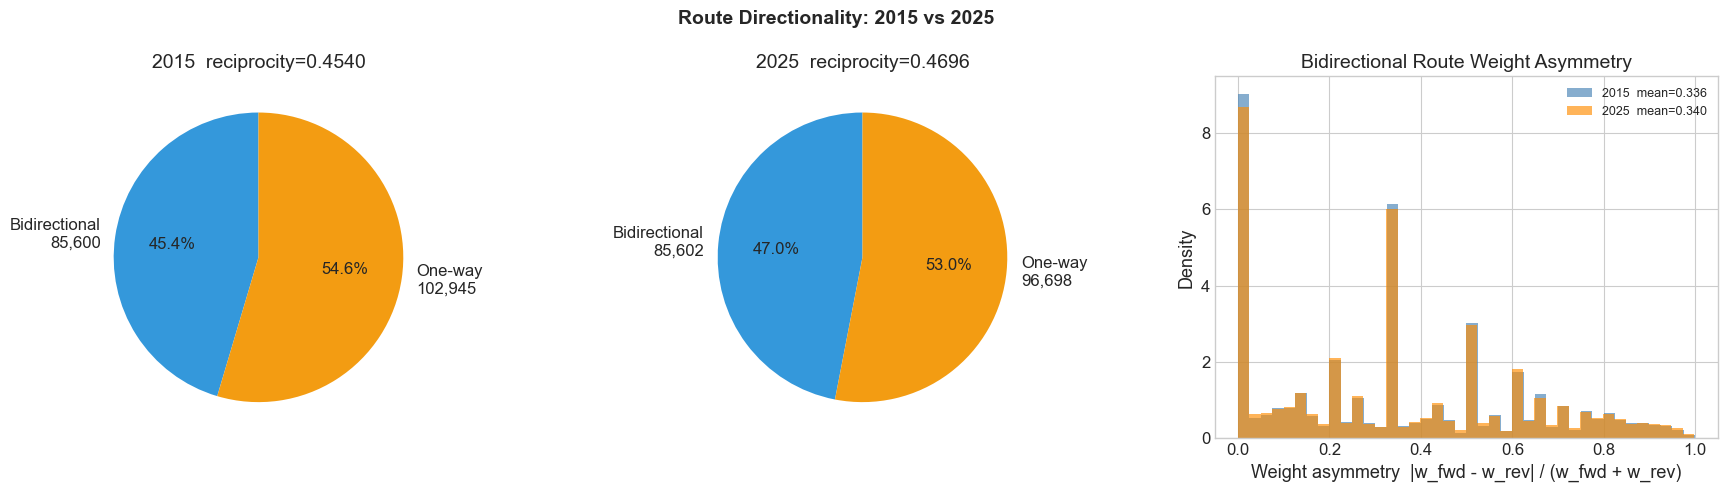

In [82]:
# Overall reciprocity
rec_2015 = nx.reciprocity(Gd_2015)
rec_2025 = nx.reciprocity(Gd_2025)

print(f'Overall reciprocity:')
print(f'  2015: {rec_2015:.4f}  ({rec_2015*100:.1f}% of edges are reciprocated)')
print(f'  2025: {rec_2025:.4f}  ({rec_2025*100:.1f}% of edges are reciprocated)')
print(f'  Change: {(rec_2025-rec_2015):+.4f}  '      f'({"more" if rec_2025>rec_2015 else "less"} bidirectional in 2025)')

# --- Reciprocated vs one-way edges ---
def reciprocal_stats(Gd):
    recip_edges, oneway_edges = [], []
    for u, v in Gd.edges():
        if Gd.has_edge(v, u):
            recip_edges.append((u, v))
        else:
            oneway_edges.append((u, v))
    return recip_edges, oneway_edges

re15, ow15 = reciprocal_stats(Gd_2015)
re25, ow25 = reciprocal_stats(Gd_2025)

print(f'\n2015: {len(re15):,} reciprocated edges, {len(ow15):,} one-way edges')
print(f'2025: {len(re25):,} reciprocated edges, {len(ow25):,} one-way edges')

# --- Weight asymmetry on reciprocated weighted routes ---
def weight_asymmetry(Gd_w, recip_edges, label):
    """For each reciprocated route u->v, compute |w(u,v) - w(v,u)| / (w(u,v) + w(v,u))."""
    asym = []
    for u, v in recip_edges:
        w_fwd = Gd_w[u][v]['weight'] if Gd_w.has_edge(u, v) else 0
        w_rev = Gd_w[v][u]['weight'] if Gd_w.has_edge(v, u) else 0
        if w_fwd + w_rev > 0:
            asym.append(abs(w_fwd - w_rev) / (w_fwd + w_rev))
    arr = np.array(asym)
    print(f'  {label}: mean weight asymmetry = {arr.mean():.4f}  '          f'(0=balanced, 1=one-directional)')
    return arr

asym_15 = weight_asymmetry(Gd_w_2015, re15, '2015')
asym_25 = weight_asymmetry(Gd_w_2025, re25, '2025')

# --- Reciprocity change: routes that gained/lost reciprocation ---
edges_15d = set(Gd_2015.edges())
edges_25d = set(Gd_2025.edges())

# Routes in both years — did reciprocation status change?
stable_routes = edges_15d & edges_25d
gained_recip  = [(u,v) for (u,v) in stable_routes
                  if not Gd_2015.has_edge(v,u) and Gd_2025.has_edge(v,u)]
lost_recip    = [(u,v) for (u,v) in stable_routes
                  if Gd_2015.has_edge(v,u) and not Gd_2025.has_edge(v,u)]

print(f'\nAmong routes present in both years:')
print(f'  Gained reciprocation (2015 one-way → 2025 bidirectional): {len(gained_recip):,}')
print(f'  Lost  reciprocation (2015 bidirectional → 2025 one-way) : {len(lost_recip):,}')

# --- Visualise ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Route Directionality: 2015 vs 2025', fontsize=14, fontweight='bold')

# Reciprocated vs one-way pie
for ax, (year, recip, oneway) in zip(axes[:2], [
    ('2015', re15, ow15), ('2025', re25, ow25)
]):
    ax.pie(
        [len(recip), len(oneway)],
        labels=[f'Bidirectional\n{len(recip):,}', f'One-way\n{len(oneway):,}'],
        autopct='%1.1f%%',
        colors=['#3498db', '#f39c12'],
        startangle=90,
    )
    ax.set_title(f'{year}  reciprocity={nx.reciprocity(Gd_2015 if year=="2015" else Gd_2025):.4f}')

# Weight asymmetry distribution
axes[2].hist(asym_15, bins=40, alpha=0.65, color=COLORS['2015'],
             density=True, label=f'2015  mean={asym_15.mean():.3f}')
axes[2].hist(asym_25, bins=40, alpha=0.65, color=COLORS['2025'],
             density=True, label=f'2025  mean={asym_25.mean():.3f}')
axes[2].set_xlabel('Weight asymmetry  |w_fwd - w_rev| / (w_fwd + w_rev)')
axes[2].set_ylabel('Density')
axes[2].set_title('Bidirectional Route Weight Asymmetry')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '03_reciprocity.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Chokepoint / Strategic Disruption Analysis

The general robustness analysis (Section 12) removes nodes by degree rank or uniformly at random.  
Here we target **named strategic chokepoints** — specific ports that control narrow sea lanes or major transshipment hubs — and measure how much the network degrades when each is individually removed.

Inspired by Ducruet & Notteboom (2012) and the 2025 resilience paper in our reference list, we answer:
> *Which single port, if disrupted, causes the largest collapse of the global cargo network?*

We report:
- **ΔGCC (%)** — reduction in Giant Connected Component size after removal
- **Δ⟨L⟩** — increase in average path length (network becomes less reachable)
- **Connectivity loss** — fraction of node pairs that lose all paths


Computing baseline APL (sampled 200 nodes) ...
Baseline  2015: GCC=0.9977  APL=3.3138
Baseline  2025: GCC=0.9962  APL=3.6542

Chokepoint disruption results:
 chokepoint year       port_id  degree  delta_gcc_pct  delta_apl
  Singapore 2015 sgp-singapore     827          0.014     0.0304
  Singapore 2025 sgp-singapore     771          0.026     0.0067
  Rotterdam 2015 nld-rotterdam     620          0.000     0.0467
  Rotterdam 2025 nld-rotterdam     520          0.039     0.0151
   Shanghai 2015  chn-shanghai    1233          0.113     0.0444
   Shanghai 2025  chn-shanghai    1171          0.065     0.0219
  Port Said 2015  egy-portsaid     504          0.000     0.0205
  Port Said 2025  egy-portsaid     474          0.013     0.0046
      Busan 2015     kor-busan     588          0.000     0.0277
      Busan 2025     kor-busan     551          0.013     0.0027
      Dubai 2015     are-dubai     139          0.014     0.0164
      Dubai 2025     are-dubai     148          0.039    -0.010

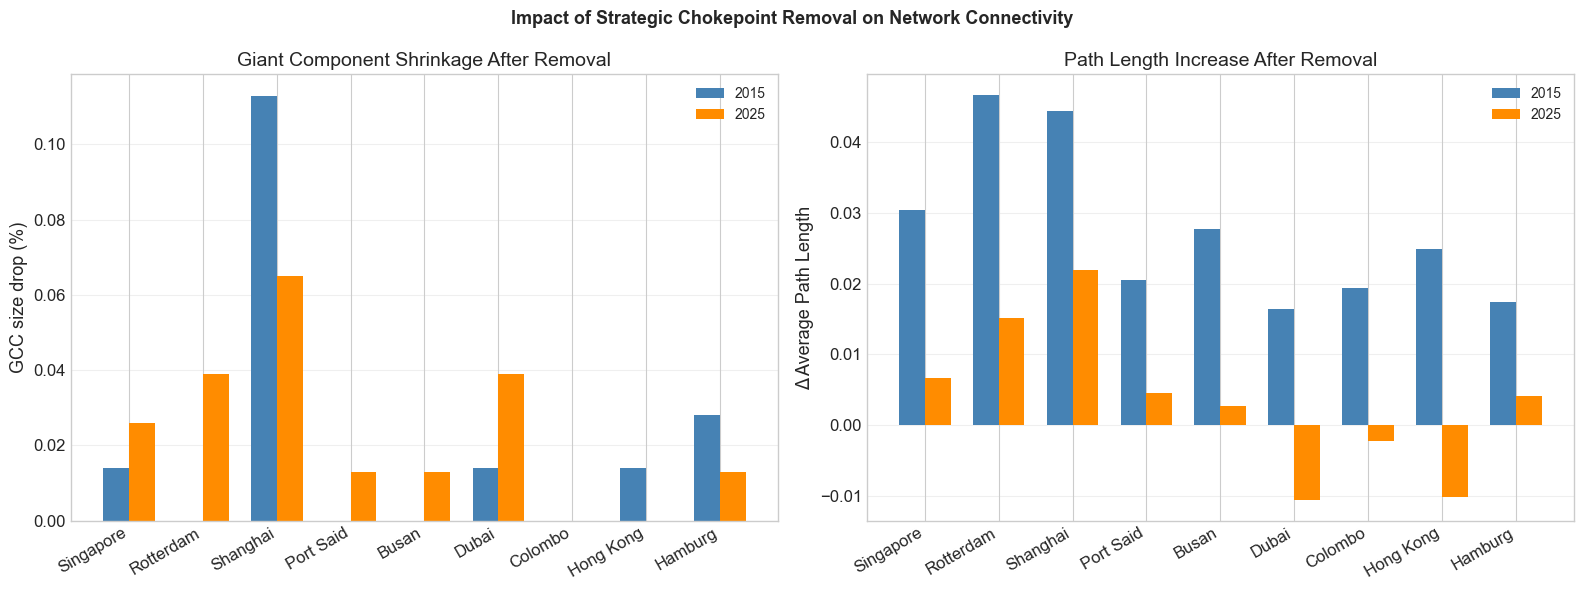


Chokepoint analysis saved → ../Figures/03_chokepoint_disruption.csv


In [83]:
# ── Strategic chokepoint ports ───────────────────────────────────────────────
# Port IDs follow GFW convention: <country_code>-<port_name_slug>
# We search for partial matches so minor name differences are handled.

CHOKEPOINTS = {
    'Singapore':   ['sgp-singapore', 'sgp-jurong', 'sgp-pasir'],
    'Rotterdam':   ['nld-rotterdam'],
    'Shanghai':    ['chn-shanghai'],
    'Port Said':   ['egy-port-said', 'egy-portsaid', 'egy-port_said'],
    'Busan':       ['kor-busan'],
    'Dubai':       ['are-dubai', 'are-jebel-ali', 'are-jebel_ali'],
    'Colombo':     ['lka-colombo'],
    'Hong Kong':   ['hkg-hong-kong', 'hkg-hongkong', 'hkg-hong_kong'],
    'Los Angeles': ['usa-los-angeles', 'usa-los_angeles', 'usa-losangeles'],
    'Hamburg':     ['deu-hamburg'],
}

def find_port(G, candidates):
    """Return the first candidate that exists as a node in G, else None."""
    nodes = set(G.nodes())
    # exact match first
    for c in candidates:
        if c in nodes:
            return c
    # substring match fallback
    slug = candidates[0].split('-', 1)[-1]  # e.g. 'singapore'
    for n in nodes:
        if slug in n:
            return n
    return None

def gcc_fraction(G):
    if G.number_of_nodes() == 0:
        return 0.0
    comps = nx.connected_components(G)
    return max(len(c) for c in comps) / G.number_of_nodes()

def sample_apl(G, n_samples=200, seed=0):
    """Quick sampled average path length on undirected graph."""
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    if len(nodes) < 2:
        return float('inf')
    src = rng.choice(nodes, size=min(n_samples, len(nodes)), replace=False)
    dists = []
    for s in src:
        lengths = nx.single_source_shortest_path_length(G, s)
        dists.extend(d for t, d in lengths.items() if t != s)
    return np.mean(dists) if dists else float('inf')

# ── Baseline metrics ─────────────────────────────────────────────────────────
base_gcc_15 = gcc_fraction(Gu_2015)
base_gcc_25 = gcc_fraction(Gu_2025)
print('Computing baseline APL (sampled 200 nodes) ...')
base_apl_15 = sample_apl(Gu_2015, n_samples=200)
base_apl_25 = sample_apl(Gu_2025, n_samples=200)
print(f'Baseline  2015: GCC={base_gcc_15:.4f}  APL={base_apl_15:.4f}')
print(f'Baseline  2025: GCC={base_gcc_25:.4f}  APL={base_apl_25:.4f}')

# ── Disruption experiment ────────────────────────────────────────────────────
results = []

for name, candidates in CHOKEPOINTS.items():
    for year, Gu, base_gcc, base_apl in [
            ('2015', Gu_2015, base_gcc_15, base_apl_15),
            ('2025', Gu_2025, base_gcc_25, base_apl_25)]:

        port = find_port(Gu, candidates)
        if port is None:
            results.append({'chokepoint': name, 'year': year,
                             'port_id': '(not found)',
                             'degree': 0, 'delta_gcc_pct': None,
                             'delta_apl': None})
            continue

        G_copy = Gu.copy()
        G_copy.remove_node(port)
        new_gcc = gcc_fraction(G_copy)
        new_apl = sample_apl(G_copy, n_samples=200)

        delta_gcc = (base_gcc - new_gcc) / base_gcc * 100   # % drop
        delta_apl = new_apl - base_apl

        results.append({
            'chokepoint': name,
            'year':       year,
            'port_id':    port,
            'degree':     Gu.degree(port),
            'delta_gcc_pct': round(delta_gcc, 3),
            'delta_apl':     round(delta_apl, 4),
        })

df_choke = pd.DataFrame(results)
print('\nChokepoint disruption results:')
print(df_choke.to_string(index=False))

# ── Visualisation ────────────────────────────────────────────────────────────
df15 = df_choke[df_choke['year'] == '2015'].dropna(subset=['delta_gcc_pct'])
df25 = df_choke[df_choke['year'] == '2025'].dropna(subset=['delta_gcc_pct'])

choke_names = df15['chokepoint'].tolist()
x = np.arange(len(choke_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact of Strategic Chokepoint Removal on Network Connectivity',
             fontsize=13, fontweight='bold')

# GCC drop
gcc_15 = df15.set_index('chokepoint')['delta_gcc_pct'].reindex(choke_names).fillna(0)
gcc_25 = df25.set_index('chokepoint')['delta_gcc_pct'].reindex(choke_names).fillna(0)
axes[0].bar(x - width/2, gcc_15, width, label='2015', color='steelblue', edgecolor='none')
axes[0].bar(x + width/2, gcc_25, width, label='2025', color='darkorange', edgecolor='none')
axes[0].set_xticks(x)
axes[0].set_xticklabels(choke_names, rotation=30, ha='right')
axes[0].set_ylabel('GCC size drop (%)')
axes[0].set_title('Giant Component Shrinkage After Removal')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# APL increase
apl_15 = df15.set_index('chokepoint')['delta_apl'].reindex(choke_names).fillna(0)
apl_25 = df25.set_index('chokepoint')['delta_apl'].reindex(choke_names).fillna(0)
axes[1].bar(x - width/2, apl_15, width, label='2015', color='steelblue', edgecolor='none')
axes[1].bar(x + width/2, apl_25, width, label='2025', color='darkorange', edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels(choke_names, rotation=30, ha='right')
axes[1].set_ylabel('Δ Average Path Length')
axes[1].set_title('Path Length Increase After Removal')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + '03_chokepoint_disruption.png', dpi=150, bbox_inches='tight')
plt.show()

df_choke.to_csv('../Figures/03_chokepoint_disruption.csv', index=False)
print('\nChokepoint analysis saved → ../Figures/03_chokepoint_disruption.csv')


---
## 16. Visual Summary Dashboard

A single figure summarising **all key structural changes** from 2015 to 2025:
- Metric-change bar chart (percentage change for each metric)
- Radar chart comparing normalised metric profiles

Gives a quick visual "fingerprint" of how the network evolved.

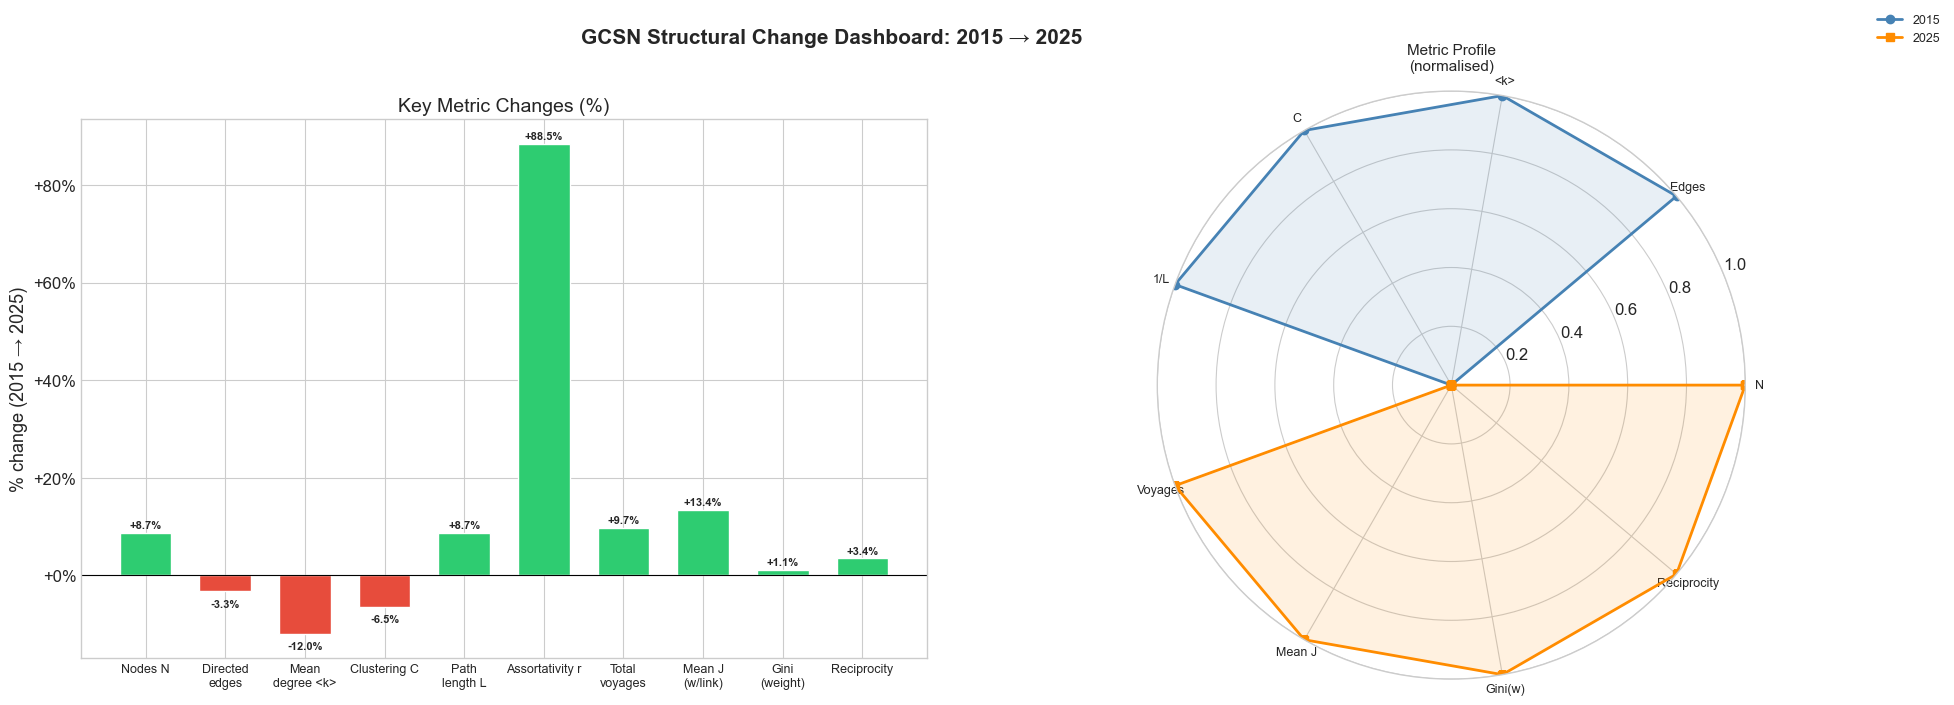

Summary dashboard saved → ../Figures/03_summary_dashboard.png


In [84]:
import matplotlib.ticker as mticker

# ── Bar chart: % change in key metrics ──────────────────────────────
metric_labels = [
    'Nodes N', 'Directed\nedges', 'Mean\ndegree <k>',
    'Clustering C', 'Path\nlength L', 'Assortativity r',
    'Total\nvoyages', 'Mean J\n(w/link)', 'Gini\n(weight)',
    'Reciprocity',
]

vals_15 = np.array([
    m15['N'], m15['E_directed'], m15['mean_k'],
    m15['C_unw'], m15['apl'], m15['assort_r'],
    m15['total_voyages'], m15['mean_J'], g_w15,
    rec_2015,
])
vals_25 = np.array([
    m25['N'], m25['E_directed'], m25['mean_k'],
    m25['C_unw'], m25['apl'], m25['assort_r'],
    m25['total_voyages'], m25['mean_J'], g_w25,
    rec_2025,
])

pct_chg = np.where(vals_15 != 0, (vals_25 - vals_15) / np.abs(vals_15) * 100, 0)
colors_bar = ['#2ecc71' if p >= 0 else '#e74c3c' for p in pct_chg]

fig, axes = plt.subplots(1, 2, figsize=(20, 7),
                          gridspec_kw={'width_ratios': [3, 2]})
fig.suptitle('GCSN Structural Change Dashboard: 2015 → 2025',
             fontsize=15, fontweight='bold', y=1.01)

# Left: bar chart
ax_bar = axes[0]
bars = ax_bar.bar(np.arange(len(metric_labels)), pct_chg,
                   color=colors_bar, edgecolor='white', width=0.65)
ax_bar.axhline(0, color='k', lw=0.8)
ax_bar.set_xticks(np.arange(len(metric_labels)))
ax_bar.set_xticklabels(metric_labels, fontsize=9)
ax_bar.set_ylabel('% change (2015 → 2025)')
ax_bar.set_title('Key Metric Changes (%)')
for bar, val in zip(bars, pct_chg):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    ax_bar.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:+.1f}%', ha='center', va='bottom' if val>=0 else 'top',
                fontsize=8, fontweight='bold')
ax_bar.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))

# Right: radar chart (normalise each metric 0–1 across both years)
radar_labels = ['N', 'Edges', '<k>', 'C', '1/L',
                'Voyages', 'Mean J', 'Gini(w)', 'Reciprocity']
radar_15 = np.array([m15['N'], m15['E_directed'], m15['mean_k'],
                      m15['C_unw'], 1/m15['apl'],
                      m15['total_voyages'], m15['mean_J'], g_w15, rec_2015])
radar_25 = np.array([m25['N'], m25['E_directed'], m25['mean_k'],
                      m25['C_unw'], 1/m25['apl'],
                      m25['total_voyages'], m25['mean_J'], g_w25, rec_2025])
# Normalise to [0,1]
combined = np.stack([radar_15, radar_25])
mn, mx = combined.min(axis=0), combined.max(axis=0)
denom = np.where(mx - mn == 0, 1, mx - mn)
r15n = (radar_15 - mn) / denom
r25n = (radar_25 - mn) / denom

n_axes = len(radar_labels)
angles = np.linspace(0, 2*np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]   # close polygon
r15n_c = np.concatenate([r15n, [r15n[0]]])
r25n_c = np.concatenate([r25n, [r25n[0]]])

ax_rad = axes[1]
ax_rad.remove()
ax_rad = fig.add_axes([0.65, 0.08, 0.32, 0.84], projection='polar')
ax_rad.plot(angles, r15n_c, 'o-', lw=2, color=COLORS['2015'], label='2015')
ax_rad.fill(angles, r15n_c, alpha=0.12, color=COLORS['2015'])
ax_rad.plot(angles, r25n_c, 's-', lw=2, color=COLORS['2025'], label='2025')
ax_rad.fill(angles, r25n_c, alpha=0.12, color=COLORS['2025'])
ax_rad.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
ax_rad.set_ylim(0, 1)
ax_rad.set_title('Metric Profile\n(normalised)', fontsize=11, pad=15)
ax_rad.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.savefig(FIG_DIR + '03_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary dashboard saved → ../Figures/03_summary_dashboard.png')
